# 🧠 Stroke Prediction — XGBoost Classifier
**Dataset:** Healthcare Stroke Dataset (5,110 patients)  
**Goal:** Predict whether a patient is likely to have a stroke based on clinical and demographic features.  
**Challenge:** Highly imbalanced target (~4.9% positive cases).

## 1. Imports & Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    average_precision_score
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, plot_importance

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = ['#4C72B0', '#DD8452']

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


## 2. Load & Inspect the Data

In [5]:
df = pd.read_csv('../datasets/healthcare-dataset-stroke-data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
print('=== Data Types & Missing Values ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().mean() * 100).round(2)
})
print(info.to_string())

=== Data Types & Missing Values ===
                     dtype  non_null  missing  missing_%
id                   int64      5110        0       0.00
gender                 str      5110        0       0.00
age                float64      5110        0       0.00
hypertension         int64      5110        0       0.00
heart_disease        int64      5110        0       0.00
ever_married           str      5110        0       0.00
work_type              str      5110        0       0.00
Residence_type         str      5110        0       0.00
avg_glucose_level  float64      5110        0       0.00
bmi                float64      4909      201       3.93
smoking_status         str      5110        0       0.00
stroke               int64      5110        0       0.00


In [7]:
print('=== Descriptive Statistics ===')
df.describe(include='all').T

=== Descriptive Statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


## 3. Exploratory Data Analysis (EDA)

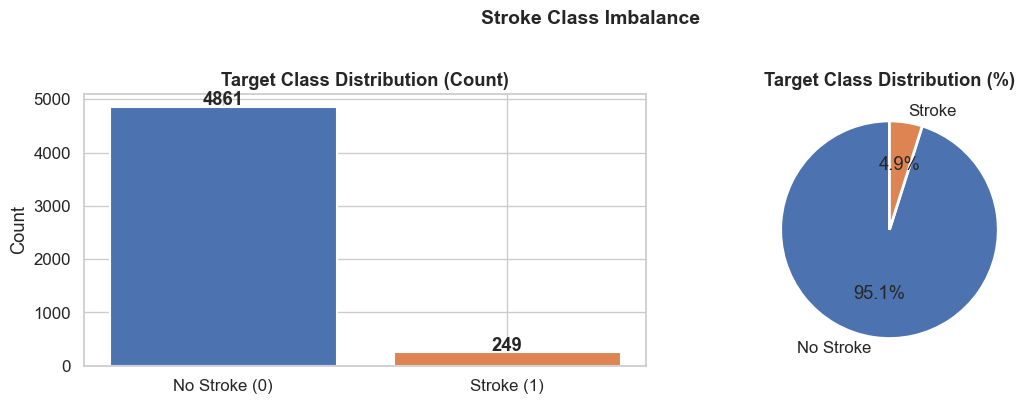

Class imbalance ratio — No Stroke : Stroke = 4861:249 (19.5:1)


In [8]:
# --- Target class distribution ---
counts = df['stroke'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Stroke (0)', 'Stroke (1)'], counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
            colors=COLORS, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Target Class Distribution (%)', fontweight='bold')

plt.suptitle('Stroke Class Imbalance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'Class imbalance ratio — No Stroke : Stroke = {counts[0]}:{counts[1]} ({counts[0]/counts[1]:.1f}:1)')

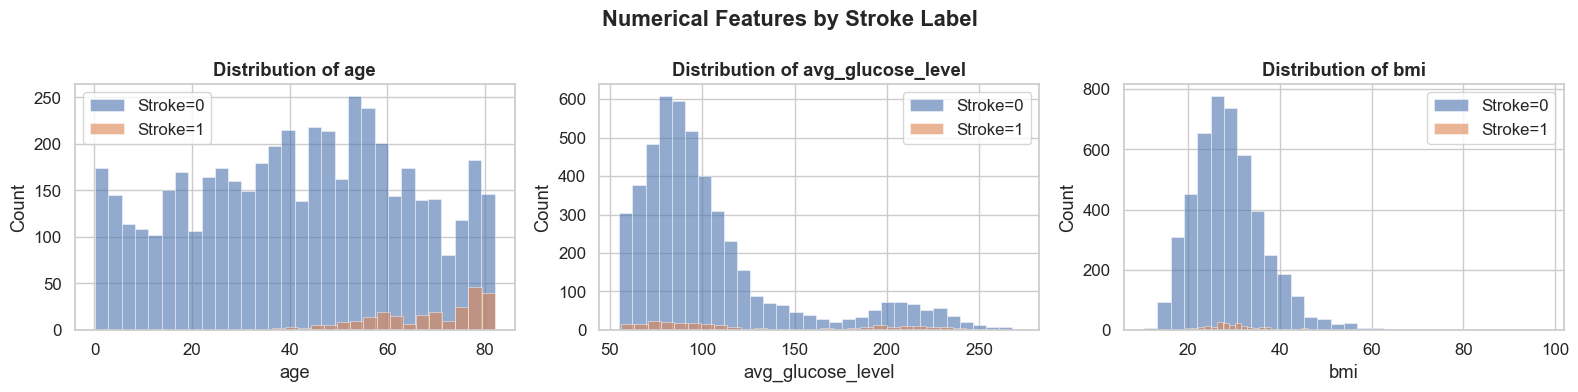

In [9]:
# --- Numerical feature distributions by stroke label ---
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, num_cols):
    for label, color in zip([0, 1], COLORS):
        subset = df[df['stroke'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f'Stroke={label}', edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Numerical Features by Stroke Label', fontweight='bold')
plt.tight_layout()
plt.show()

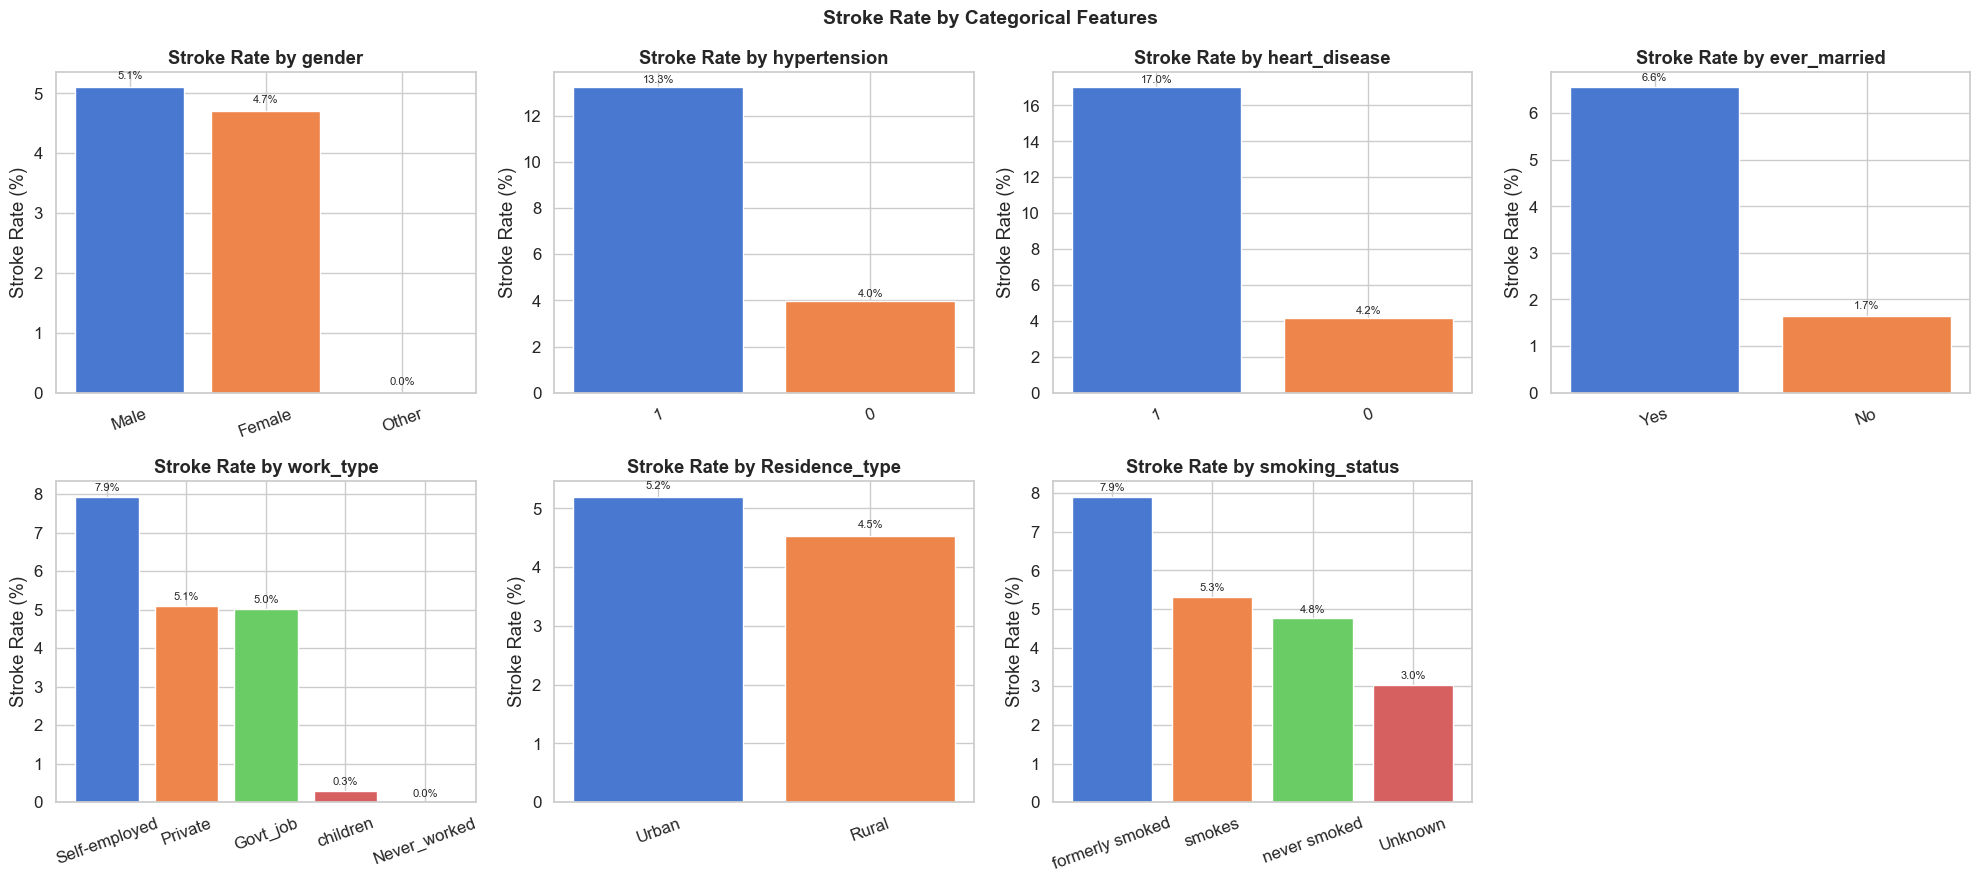

In [10]:
# --- Categorical features vs stroke rate ---
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(stroke_rate.index.astype(str), stroke_rate.values,
                  color=sns.color_palette('muted', len(stroke_rate)), edgecolor='white')
    ax.set_title(f'Stroke Rate by {col}', fontweight='bold')
    ax.set_ylabel('Stroke Rate (%)')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Stroke Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

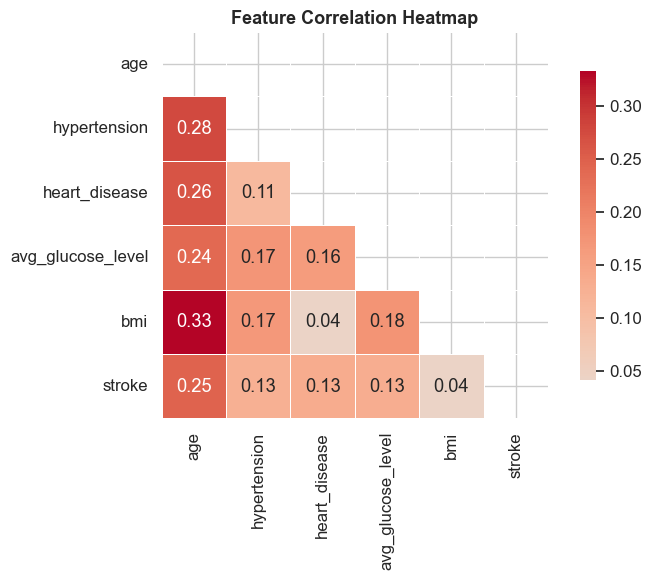

In [11]:
# --- Correlation heatmap (numerical only) ---
num_df = df[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']]
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [12]:
# --- Drop id column (not predictive) ---
data = df.drop(columns=['id']).copy()

# --- Remove 'Other' gender (only 1 row — too sparse) ---
data = data[data['gender'] != 'Other'].reset_index(drop=True)
print(f'Rows after removing gender="Other": {len(data)}')

# --- Impute missing BMI with median (stratified by stroke to avoid leakage) ---
bmi_median = data.loc[data['bmi'].notnull(), 'bmi'].median()
data['bmi'] = data['bmi'].fillna(bmi_median)
print(f'BMI missing values after imputation: {data["bmi"].isnull().sum()}')

Rows after removing gender="Other": 5109
BMI missing values after imputation: 0


In [44]:
# --- Feature Engineering
df['age_x_hypertension'] = df['age'] * df['hypertension']
df['glucose_risk'] = (df['avg_glucose_level'] > 140).astype(int)
df['risk_score'] = df['age'] * (1+df['hypertension'] + df['heart_disease'])

In [45]:
# --- Encode categorical variables ---
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

le = LabelEncoder()
for col in cat_features:
    data[col] = le.fit_transform(data[col].astype(str))
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nFinal feature dtypes:')
print(data.dtypes)

gender: {'0': np.int64(0), '1': np.int64(1)}
ever_married: {'0': np.int64(0), '1': np.int64(1)}
work_type: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3), '4': np.int64(4)}
Residence_type: {'0': np.int64(0), '1': np.int64(1)}
smoking_status: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3)}

Final feature dtypes:
gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object


In [46]:
# --- Feature / Target split ---
X = data.drop(columns=['stroke'])
y = data['stroke']

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Target distribution:\n{y.value_counts(normalize=True).mul(100).round(2)}')

Features: 10 | Samples: 5109
Target distribution:
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


In [47]:
# --- Stratified train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Train stroke rate: {y_train.mean():.3f} | Test stroke rate: {y_test.mean():.3f}')

Train: 4087 rows | Test: 1022 rows
Train stroke rate: 0.049 | Test stroke rate: 0.049


In [58]:
# --- Apply SMOTE on training set only ---
smote = SMOTE(sampling_strategy=0.33, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After  SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}')

Before SMOTE: {0: 3888, 1: 199}
After  SMOTE: {0: 3888, 1: 1283}


## 5. XGBoost Model Training

In [68]:
# --- Compute scale_pos_weight for native imbalance handling (used as reference) ---
neg, pos = np.bincount(y_train)
scale_pw = neg / pos
print(f'scale_pos_weight (for reference): {scale_pw:.2f}')

# --- Define model (trained on SMOTE-balanced data) ---
xgb_model = XGBClassifier(
    scale_pos_weight=20,  # Adjusted for imbalance (reference: ~20)
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,           # L1 regularisation
    reg_lambda=1.0,           # L2 regularisation
    min_child_weight=5,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

# --- Fit with early stopping on a validation split ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res, test_size=0.15, random_state=SEED, stratify=y_train_res
)

xgb_model.set_params(n_estimators=1000, early_stopping_rounds=30)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f'\nBest iteration: {xgb_model.best_iteration}')

scale_pos_weight (for reference): 19.54
[0]	validation_0-auc:0.85652
[50]	validation_0-auc:0.90801
[100]	validation_0-auc:0.92578
[150]	validation_0-auc:0.93578
[200]	validation_0-auc:0.93970
[250]	validation_0-auc:0.94471
[300]	validation_0-auc:0.94665
[350]	validation_0-auc:0.94884
[400]	validation_0-auc:0.95048
[450]	validation_0-auc:0.95173
[500]	validation_0-auc:0.95359
[550]	validation_0-auc:0.95496
[600]	validation_0-auc:0.95574
[650]	validation_0-auc:0.95653
[700]	validation_0-auc:0.95745
[750]	validation_0-auc:0.95873
[800]	validation_0-auc:0.95915
[841]	validation_0-auc:0.95938

Best iteration: 811


## 6. Model Evaluation

In [73]:
# --- Predictions ---
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Tune threshold for recall (medical context: minimise missed strokes)
THRESHOLD = 0.45
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

print(f'Classification threshold: {THRESHOLD}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)
print(f'ROC-AUC Score : {roc_auc:.4f}')
print(f'PR-AUC Score  : {pr_auc:.4f}')

Classification threshold: 0.45

=== Classification Report ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.81      0.89       972
      Stroke       0.15      0.66      0.25        50

    accuracy                           0.81      1022
   macro avg       0.57      0.74      0.57      1022
weighted avg       0.94      0.81      0.86      1022

ROC-AUC Score : 0.7934
PR-AUC Score  : 0.1632


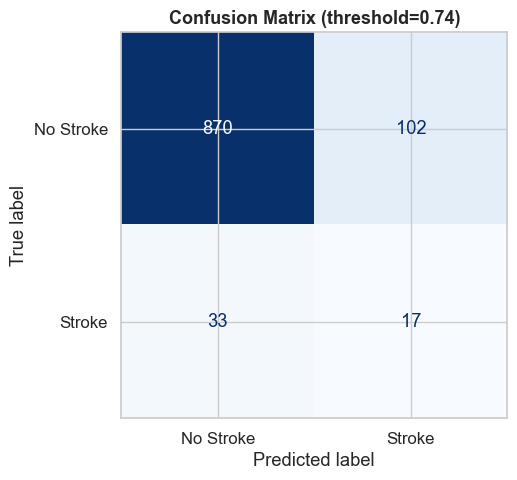

In [70]:
# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

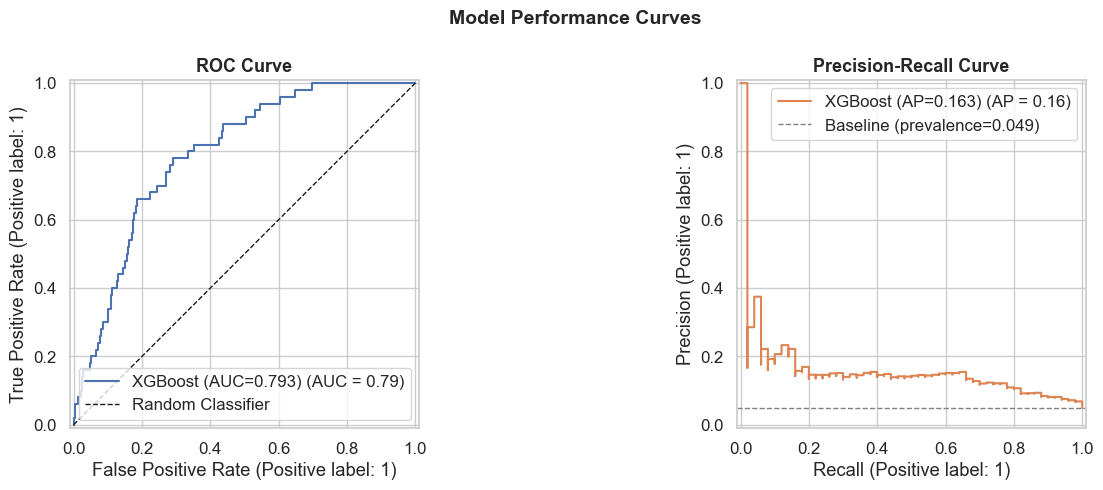

In [71]:
# --- ROC Curve & PR Curve side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0],
                                   name=f'XGBoost (AUC={roc_auc:.3f})',
                                   color=COLORS[0])
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[0].legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1],
                                         name=f'XGBoost (AP={pr_auc:.3f})',
                                         color=COLORS[1])
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', linewidth=1,
                label=f'Baseline (prevalence={baseline:.3f})')
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[1].legend()

plt.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best threshold for Stroke F1: 0.45  (F1=0.249, Recall=0.660, Precision=0.153)


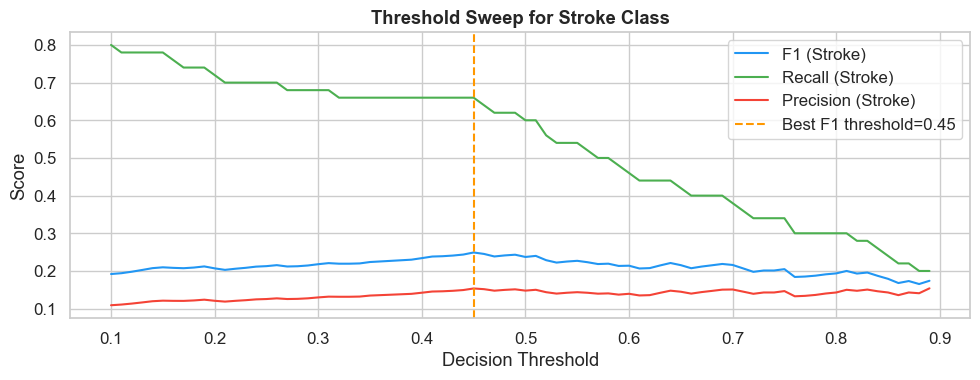

In [72]:
# --- Threshold sweep: find best F1 for Stroke class ---
thresholds = np.arange(0.1, 0.9, 0.01)
results = []
for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    from sklearn.metrics import f1_score, recall_score, precision_score
    results.append({
        'threshold': t,
        'f1_stroke':        f1_score(y_test, preds, pos_label=1, zero_division=0),
        'recall_stroke':    recall_score(y_test, preds, pos_label=1, zero_division=0),
        'precision_stroke': precision_score(y_test, preds, pos_label=1, zero_division=0)
    })

sweep = pd.DataFrame(results)
best_t = sweep.loc[sweep['f1_stroke'].idxmax()]
print(f'Best threshold for Stroke F1: {best_t["threshold"]:.2f}  '
      f'(F1={best_t["f1_stroke"]:.3f}, '
      f'Recall={best_t["recall_stroke"]:.3f}, '
      f'Precision={best_t["precision_stroke"]:.3f})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sweep['threshold'], sweep['f1_stroke'],        label='F1 (Stroke)',        color='#2196F3')
ax.plot(sweep['threshold'], sweep['recall_stroke'],    label='Recall (Stroke)',    color='#4CAF50')
ax.plot(sweep['threshold'], sweep['precision_stroke'], label='Precision (Stroke)', color='#F44336')
ax.axvline(best_t['threshold'], color='#FF9800', linestyle='--', label=f'Best F1 threshold={best_t["threshold"]:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sweep for Stroke Class', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [74]:
# --- Cross-validation (on original imbalanced data, using ROC-AUC) ---
print('Running 5-fold Stratified Cross-Validation on training set...')
cv_model = XGBClassifier(
    n_estimators=xgb_model.best_iteration,
    max_depth=4, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    min_child_weight=5, eval_metric='auc',
    use_label_encoder=False, random_state=SEED, n_jobs=-1
)
cv_scores = cross_val_score(
    cv_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1
)
print(f'CV ROC-AUC scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Running 5-fold Stratified Cross-Validation on training set...
CV ROC-AUC scores: [0.8116 0.8408 0.8173 0.7713 0.8151]
Mean: 0.8112 ± 0.0224


## 7. Feature Importance

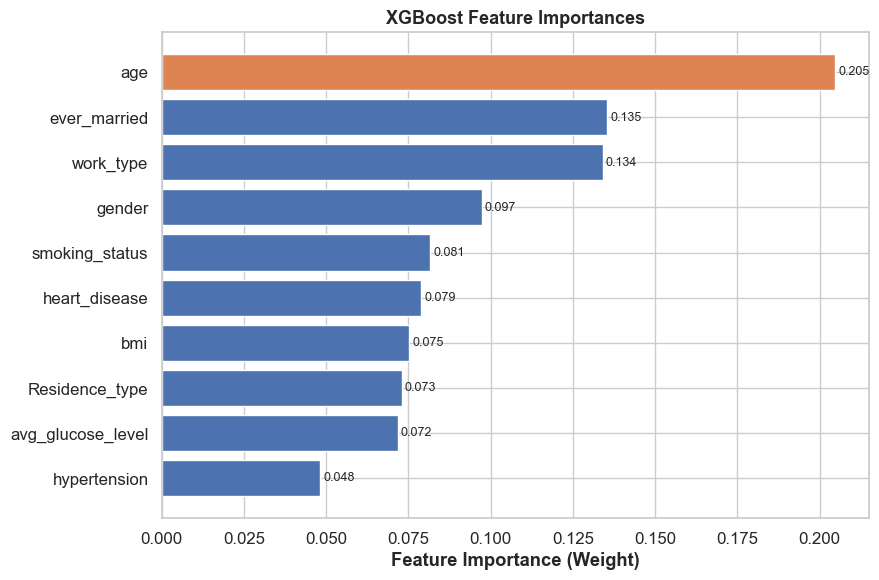


Top 5 most important features:
age               0.204792
ever_married      0.135410
work_type         0.134023
gender            0.097272
smoking_status    0.081467
dtype: float32


In [75]:
# --- XGBoost built-in importance (gain) ---
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)\
             .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = [COLORS[1] if x == feat_imp.max() else COLORS[0] for x in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_bar, edgecolor='white')
ax.set_xlabel('Feature Importance (Weight)', fontweight='bold')
ax.set_title('XGBoost Feature Importances', fontweight='bold', fontsize=13)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp.sort_values(ascending=False).head())

## 8. Training Curve (Early Stopping History)

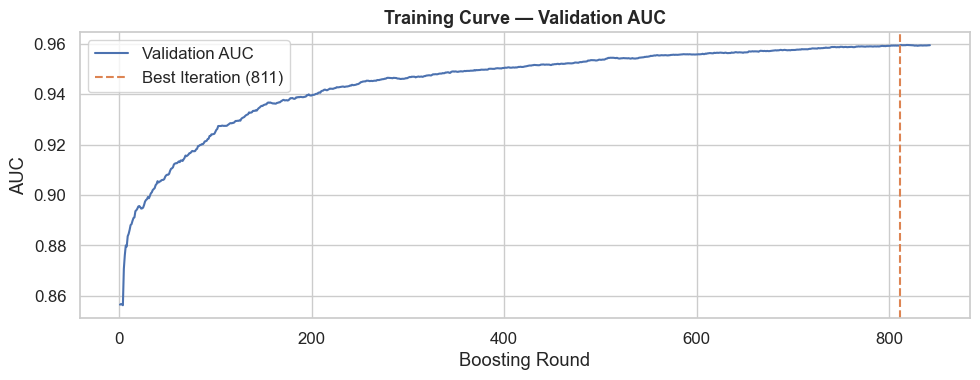

In [76]:
# --- Plot validation AUC vs. iterations ---
eval_results = xgb_model.evals_result()
val_auc = eval_results['validation_0']['auc']
iters   = range(1, len(val_auc) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(iters, val_auc, color=COLORS[0], linewidth=1.5, label='Validation AUC')
ax.axvline(xgb_model.best_iteration, color=COLORS[1], linestyle='--',
           label=f'Best Iteration ({xgb_model.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUC')
ax.set_title('Training Curve — Validation AUC', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary

In [77]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

summary = pd.DataFrame({
    'Metric': ['ROC-AUC', 'PR-AUC', 'Accuracy', 'Precision (Stroke)',
               'Recall (Stroke)', 'F1 (Stroke)', 'CV ROC-AUC (mean ± std)'],
    'Value': [
        f'{roc_auc:.4f}',
        f'{pr_auc:.4f}',
        f'{accuracy_score(y_test, y_pred):.4f}',
        f'{precision_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}',
        f'{recall_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}',
        f'{f1_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}',
        f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}'
    ]
})

print('='*45)
print('     FINAL MODEL PERFORMANCE SUMMARY')
print('='*45)
print(summary.to_string(index=False))
print('='*45)
print(f'\nDecision threshold used: {THRESHOLD}')
print(f'Best XGBoost iteration : {xgb_model.best_iteration}')
print(f'\nTop predictors: {feat_imp.sort_values(ascending=False).index[:3].tolist()}')

     FINAL MODEL PERFORMANCE SUMMARY
                 Metric           Value
                ROC-AUC          0.7934
                 PR-AUC          0.1632
               Accuracy          0.8053
     Precision (Stroke)          0.1535
        Recall (Stroke)          0.6600
            F1 (Stroke)          0.2491
CV ROC-AUC (mean ± std) 0.8112 ± 0.0224

Decision threshold used: 0.45
Best XGBoost iteration : 811

Top predictors: ['age', 'ever_married', 'work_type']
